# s3100_200f-Slice — Selector-Vergleich (amtown03, frames 3100..3299)

Eigener Loader auf `output/s3100_200f_results.csv`. Die folgenden Zellen zeigen:
1. Bar-Charts: Variant × (Laufzeit, PSNR, Mapped-KFs)
2. Pareto: Laufzeit ↔ PSNR
3. Scatter: Laufzeit ↔ Mapped-KFs
4. Scatter: PSNR ↔ Mapped-KFs
5. Per-Frame-Histogramm: für jeden Frame-Index 0..199, wie viele Selektoren ihn akzeptiert haben (ohne `mapskip` / `skip_no_filter`).

Hinweis: `n_keyframes` in der CSV = Tracker-KFs (für Selector-Runs immer 192). Was zwischen Selektoren variiert ist `n_mapped` (= Selector-Accepts → Mapper-Inputs); deshalb plotten wir das.

In [16]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

# Wie scripts/log_sweep_row.py — finditer pro Zeile (tqdm-Escapes).
_KF_LINE_RX = re.compile(rb"\[\s*(\d+)\]\s+kf=([YNS])")


def parse_mapped_frames(log_path: Path) -> np.ndarray:
    """Frame-Indizes mit kf=Y (Selector-Accept → Mapper) aus run_*.log."""
    if not log_path.exists():
        return np.array([], dtype=np.int64)
    frames = []
    with open(log_path, "rb") as f:
        for raw in f:
            for m in _KF_LINE_RX.finditer(raw):
                if m.group(2) == b"Y":
                    frames.append(int(m.group(1)))
    return np.asarray(frames, dtype=np.int64)


In [17]:
REPO = Path('/home/philipp/Dokumente/Github/VINGS-Mono-BA')

CSV_S3100 = REPO / 'output' / 's3100_200f_results.csv'
df_s3100 = pd.read_csv(CSV_S3100)
df_s3100 = df_s3100.sort_values('timestamp_start').drop_duplicates(['variant'], keep='last').reset_index(drop=True)
df_s3100 = df_s3100[df_s3100['status'] == 'OK'].reset_index(drop=True)
print(f'OK runs: {len(df_s3100)}')
print(df_s3100.groupby('group').size())

OK runs: 49
group
adaptive_kf       4
aim               4
baseline          1
coko              4
game              4
mapskip           6
mm3dgs            4
nurbs             4
orbslam           4
skip_no_filter    6
two_gate          4
vista             4
dtype: int64


## 1) Bar-Charts pro Variant — Laufzeit, PSNR, Mapped-KFs

Sortiert pro Gruppe; Farbe = Gruppe. `vings_filter`-Baseline ist als Referenz mit dabei.

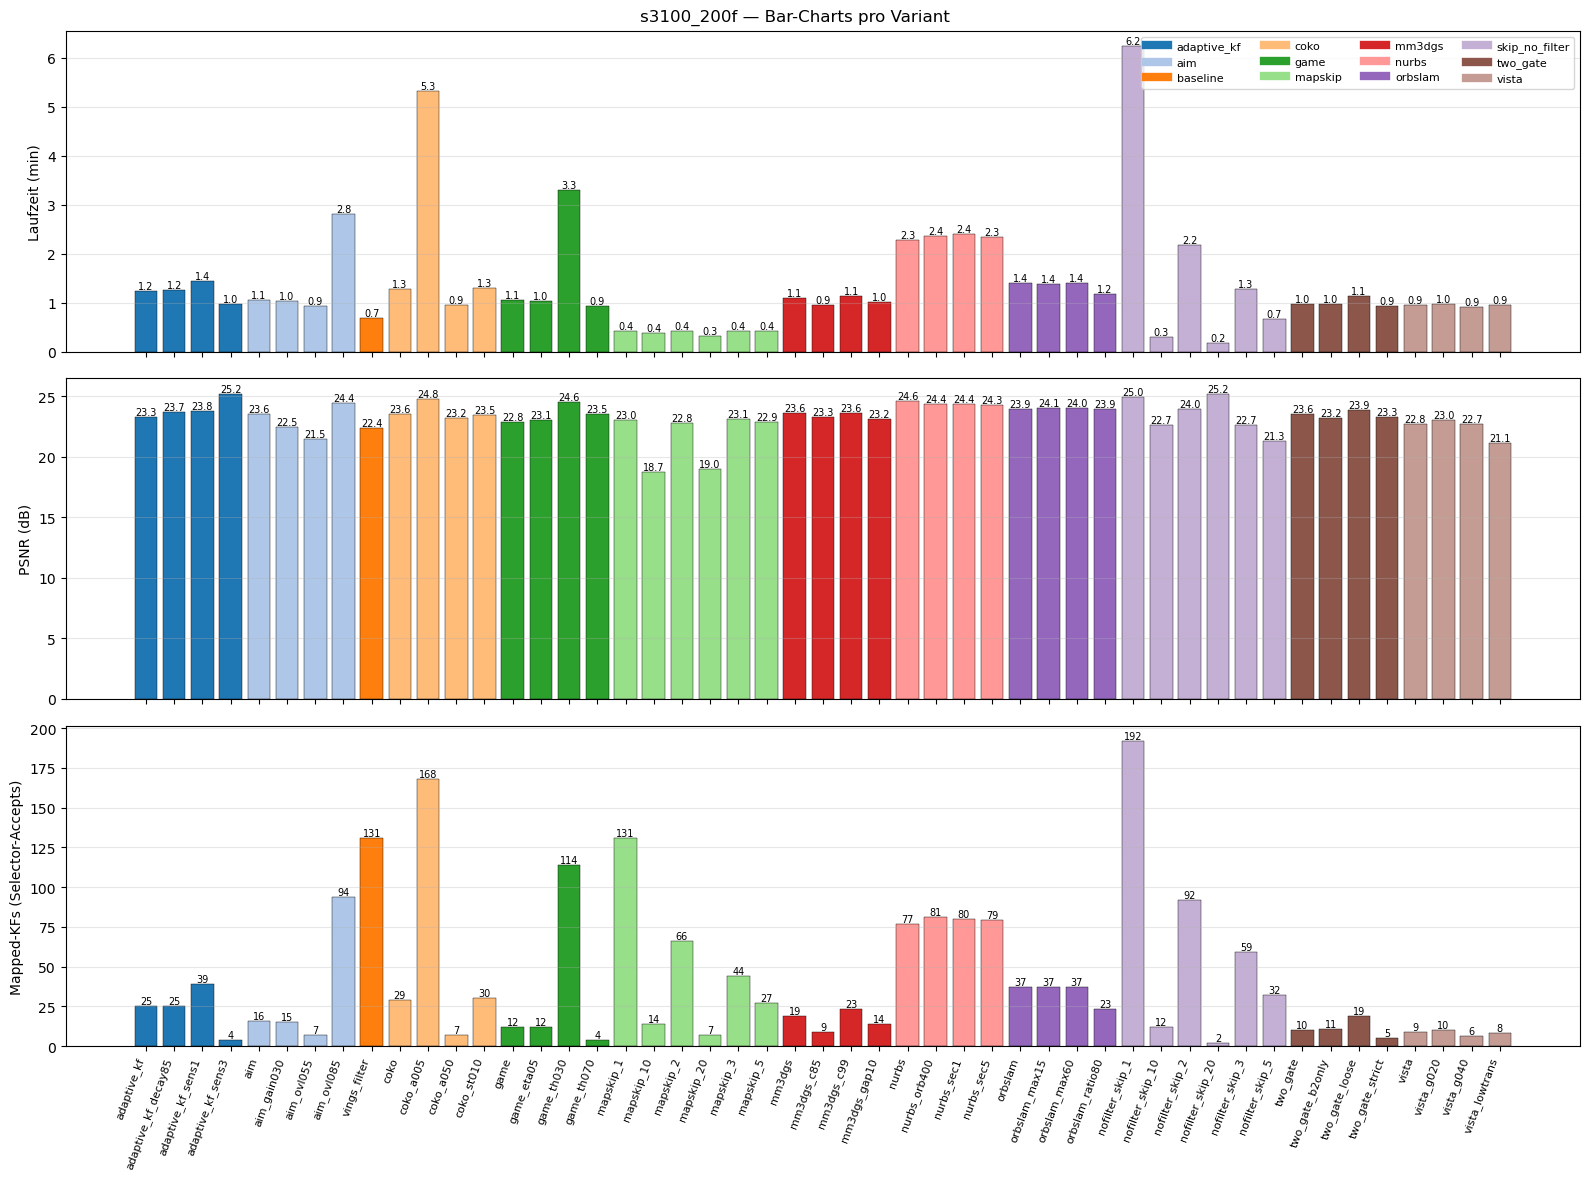

In [18]:
GROUPS_S = sorted(df_s3100['group'].unique())
GROUP_COLOR_S = dict(zip(GROUPS_S, plt.cm.tab20.colors[:len(GROUPS_S)]))

df_plot = df_s3100.sort_values(['group','variant']).reset_index(drop=True)
labels  = df_plot['variant'].tolist()
colors  = [GROUP_COLOR_S[g] for g in df_plot['group']]
x = np.arange(len(labels))

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
metrics = [
    ('duration_min', 'Laufzeit (min)', axes[0]),
    ('psnr',         'PSNR (dB)',       axes[1]),
    ('n_mapped',     'Mapped-KFs (Selector-Accepts)', axes[2]),
]
for col, ylabel, ax in metrics:
    ax.bar(x, df_plot[col], color=colors, edgecolor='black', linewidth=0.3)
    ax.set_ylabel(ylabel); ax.grid(alpha=0.3, axis='y')
    for xi, v in zip(x, df_plot[col]):
        ax.text(xi, v, f'{v:.1f}' if col != 'n_mapped' else f'{int(v)}', ha='center', va='bottom', fontsize=7)

axes[-1].set_xticks(x); axes[-1].set_xticklabels(labels, rotation=70, ha='right', fontsize=8)
legend_handles = [Line2D([0],[0], color=GROUP_COLOR_S[g], lw=6, label=g) for g in GROUPS_S]
axes[0].legend(handles=legend_handles, loc='upper right', ncol=4, fontsize=8)
fig.suptitle('s3100_200f — Bar-Charts pro Variant', fontsize=12)
fig.tight_layout(); plt.show()

## 2) Pareto-Front — PSNR vs Laufzeit

Ein Config ist *Pareto-optimal*, wenn kein anderer gleichzeitig höher PSNR **und** kürzere Laufzeit hat.
Vorgehen: nach `duration_min` aufsteigend sortieren, links→rechts laufen, jeden Punkt behalten der einen neuen PSNR-Höchststand setzt.

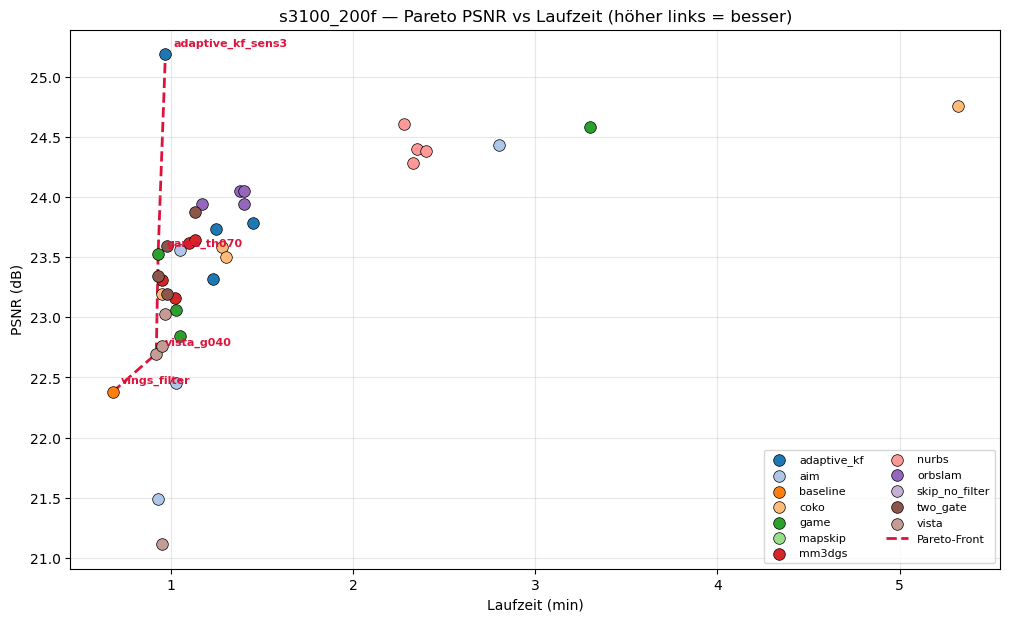

Pareto-Front (kürzeste Laufzeit → höchster PSNR):
      group           variant  duration_min    psnr  n_mapped  n_metric_frames
   baseline      vings_filter          0.68 22.3791       131                7
      vista        vista_g040          0.92 22.6976         6                6
       game        game_th070          0.93 23.5262         4                4
adaptive_kf adaptive_kf_sens3          0.97 25.1883         4                4


In [19]:
def pareto_front(df, x='duration_min', y='psnr'):
    s = df.sort_values(x).reset_index(drop=True)
    best = -np.inf; mask = []
    for v in s[y]:
        if v > best:
            mask.append(True); best = v
        else:
            mask.append(False)
    s['on_front'] = mask
    return s

# Filter mapskip, skip_no_filter
df_s3100 = df_s3100[~df_s3100['group'].isin(['mapskip', 'skip_no_filter'])].copy()

pf = pareto_front(df_s3100, 'duration_min', 'psnr')
front = pf[pf['on_front']].sort_values('duration_min')

fig, ax = plt.subplots(figsize=(12, 7))
for g in GROUPS_S:
    sub = pf[pf['group']==g]
    ax.scatter(sub['duration_min'], sub['psnr'], s=70, color=GROUP_COLOR_S[g], label=g, edgecolor='black', linewidth=0.5, zorder=2)
ax.plot(front['duration_min'], front['psnr'], color='crimson', lw=2, ls='--', zorder=1, label='Pareto-Front')
for _, r in front.iterrows():
    ax.annotate(r['variant'], (r['duration_min'], r['psnr']),
                xytext=(6, 6), textcoords='offset points', fontsize=8, color='crimson', fontweight='bold')
ax.set_xlabel('Laufzeit (min)'); ax.set_ylabel('PSNR (dB)')
ax.set_title('s3100_200f — Pareto PSNR vs Laufzeit (höher links = besser)')
ax.grid(alpha=0.3); ax.legend(loc='lower right', ncol=2, fontsize=8)
plt.show()

print('Pareto-Front (kürzeste Laufzeit → höchster PSNR):')
print(front[['group','variant','duration_min','psnr','n_mapped','n_metric_frames']].to_string(index=False))

## 3) Scatter — Laufzeit vs Mapped-KFs

Sanity-Check: lineare Beziehung erwartet (jeder Mapper-Run kostet ~0.7-1.0 s). Outlier = Selektor mit hohem Overhead pro Frame.

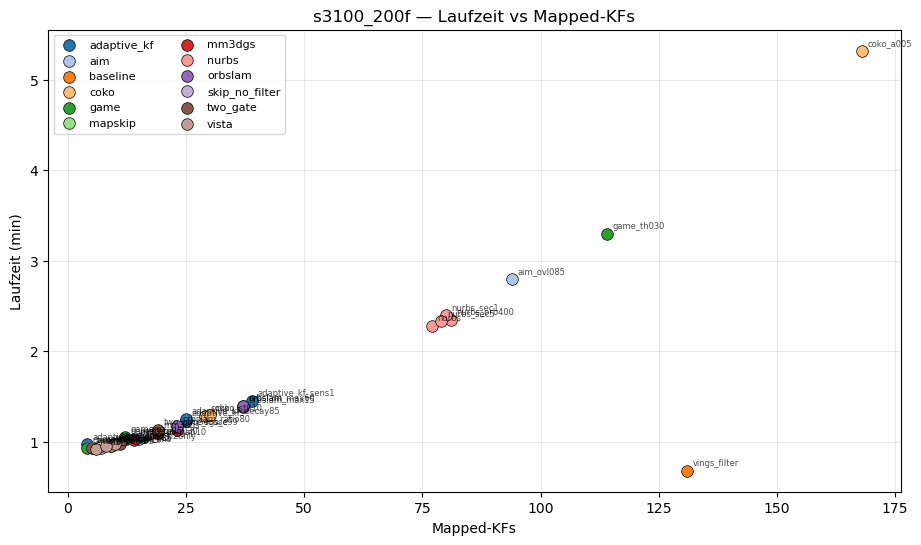

In [20]:
fig, ax = plt.subplots(figsize=(11, 6))
for g in GROUPS_S:
    sub = df_s3100[df_s3100['group']==g]
    ax.scatter(sub['n_mapped'], sub['duration_min'], s=70, color=GROUP_COLOR_S[g], label=g, edgecolor='black', linewidth=0.5)
    for _, r in sub.iterrows():
        ax.annotate(r['variant'], (r['n_mapped'], r['duration_min']),
                    xytext=(4, 4), textcoords='offset points', fontsize=6, alpha=0.7)
ax.set_xlabel('Mapped-KFs'); ax.set_ylabel('Laufzeit (min)')
ax.set_title('s3100_200f — Laufzeit vs Mapped-KFs')
ax.grid(alpha=0.3); ax.legend(loc='best', ncol=2, fontsize=8)
plt.show()

## 4) Scatter — PSNR vs Mapped-KFs

Hier sieht man, ob mehr Mapping wirklich PSNR kauft, oder ob es ab einem Punkt sättigt.

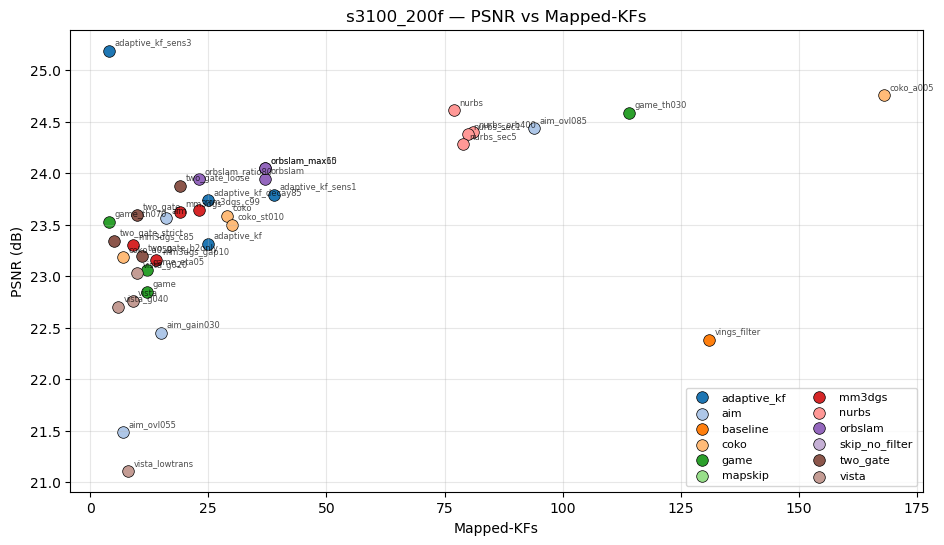

In [21]:
fig, ax = plt.subplots(figsize=(11, 6))
for g in GROUPS_S:
    sub = df_s3100[df_s3100['group']==g]
    ax.scatter(sub['n_mapped'], sub['psnr'], s=70, color=GROUP_COLOR_S[g], label=g, edgecolor='black', linewidth=0.5)
    for _, r in sub.iterrows():
        ax.annotate(r['variant'], (r['n_mapped'], r['psnr']),
                    xytext=(4, 4), textcoords='offset points', fontsize=6, alpha=0.7)
ax.set_xlabel('Mapped-KFs'); ax.set_ylabel('PSNR (dB)')
ax.set_title('s3100_200f — PSNR vs Mapped-KFs')
ax.grid(alpha=0.3); ax.legend(loc='best', ncol=2, fontsize=8)
plt.show()

## 5) Per-Frame-Konsens — Welche Frames wählen viele Selektoren?

Pro Frame-Index 0..199: wie viele Selektor-Variants haben `kf=Y` gesetzt. Nur Selektoren (kein `mapskip`, kein `skip_no_filter`, kein `baseline`). Parsing-Helper aus dem oberen Notebook (Cell 10) wird wiederverwendet.

Selector runs: 36


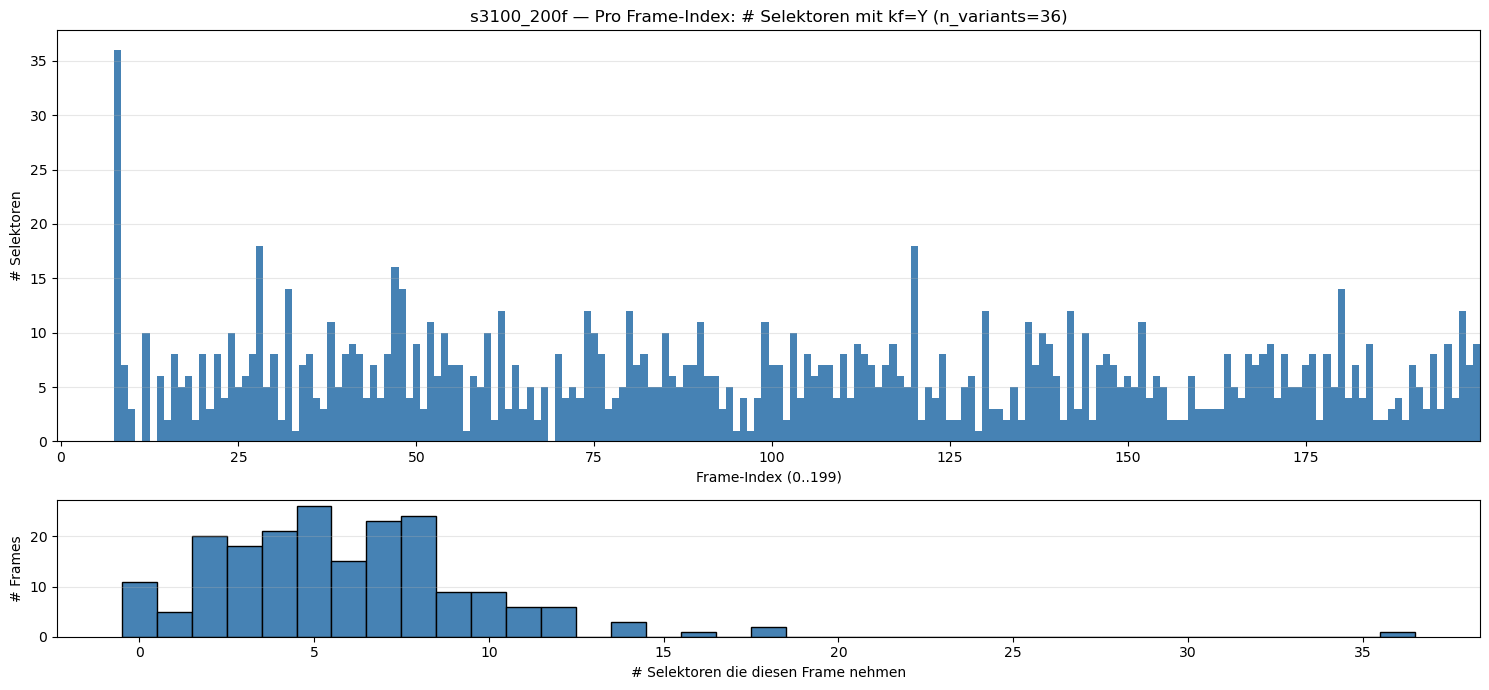

Top-10 Konsens-Frames:
  frame   8: 36 Selektoren
  frame  28: 18 Selektoren
  frame 120: 18 Selektoren
  frame  47: 16 Selektoren
  frame  48: 14 Selektoren
  frame  32: 14 Selektoren
  frame 180: 14 Selektoren
  frame  74: 12 Selektoren
  frame  80: 12 Selektoren
  frame 142: 12 Selektoren


In [22]:
SELECTOR_ONLY = df_s3100[~df_s3100['group'].isin(['baseline','mapskip','skip_no_filter'])].copy()
print(f'Selector runs: {len(SELECTOR_ONLY)}')

frames_by_variant_s = {}
for _, r in SELECTOR_ONLY.iterrows():
    if pd.isna(r['log_path']):
        continue
    arr = parse_mapped_frames(Path(r['log_path']))
    if len(arr) == 0:
        continue
    frames_by_variant_s[r['variant']] = np.unique(arr)

N = 200
consensus = np.zeros(N, dtype=np.int32)
for v, frames in frames_by_variant_s.items():
    valid = frames[frames < N]
    consensus[valid] += 1

fig, axes = plt.subplots(2, 1, figsize=(15, 7), gridspec_kw={'height_ratios':[3,1]})
axes[0].bar(np.arange(N), consensus, width=1.0, color='steelblue', edgecolor='none')
axes[0].set_title(f's3100_200f — Pro Frame-Index: # Selektoren mit kf=Y (n_variants={len(frames_by_variant_s)})')
axes[0].set_xlabel('Frame-Index (0..199)'); axes[0].set_ylabel('# Selektoren')
axes[0].set_xlim(-0.5, N-0.5); axes[0].grid(alpha=0.3, axis='y')

bins = np.arange(0, len(frames_by_variant_s)+2) - 0.5
axes[1].hist(consensus, bins=bins, color='steelblue', edgecolor='black')
axes[1].set_xlabel('# Selektoren die diesen Frame nehmen'); axes[1].set_ylabel('# Frames')
axes[1].grid(alpha=0.3, axis='y')
fig.tight_layout(); plt.show()

# Tabelle: Top-Consensus-Frames
top = np.argsort(-consensus)[:10]
print('Top-10 Konsens-Frames:')
for idx in top:
    print(f'  frame {idx:3d}: {consensus[idx]} Selektoren')

## 6) Per-Selektor-Grid — welche Frames hat jeder Algorithmus gemappt?

Ein kleines Subplot pro Selektor-Variant. X-Achse = Frame-Index (0..199),
Y-Achse = 1 wenn der Selektor diesen Frame an den Mapper gegeben hat (`kf=Y`), sonst 0.
Hilft zu sehen *wo* in der Sequenz ein Algorithmus dicht/sparsam selektiert.


In [ ]:
import math

# Re-use frames_by_variant_s from previous cell (s3100) / frames_by_variant from s1000 nb.
fbv = frames_by_variant_s
N   = 200

# Sort variants by group then name for nicer layout.
df_sel = df_s3100[~df_s3100['group'].isin(['baseline','mapskip','skip_no_filter'])]
ordered = (df_sel.sort_values(['group','variant'])['variant'].tolist())
variants = [v for v in ordered if v in fbv]
print(f'Variants in grid: {len(variants)}')

ncols = 4
nrows = math.ceil(len(variants) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4.0, nrows*1.3), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

var_to_group = dict(zip(df_s3100['variant'], df_s3100['group']))

for ax, v in zip(axes, variants):
    frames = fbv[v]
    mask = np.zeros(N, dtype=np.int8)
    valid = frames[frames < N]
    mask[valid] = 1
    g = var_to_group.get(v, 'sel')
    col = GROUP_COLOR_S.get(g, 'steelblue')
    ax.bar(np.arange(N), mask, width=1.0, color=col, edgecolor='none')
    ax.set_title(f'{v}  (n={int(mask.sum())})', fontsize=8)
    ax.set_ylim(0, 1.05); ax.set_yticks([])
    ax.set_xlim(-0.5, N-0.5)
    ax.tick_params(axis='x', labelsize=7)
    ax.grid(False)

# Hide unused subplots
for ax in axes[len(variants):]:
    ax.axis('off')

for ax in axes[-ncols:]:
    ax.set_xlabel('Frame-Index', fontsize=7)

fig.suptitle('s3100_200f — Welche Frames hat jeder Selektor an den Mapper gegeben?', fontsize=11)
fig.tight_layout()
plt.show()
